# Assignment 1 — QANet

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

Run each section in order. Sections 0–1 are one-time setup steps; Sections 2–4 are the main training and evaluation pipeline.

In [1]:
import os

# ── Local path: adjust if your repo is stored elsewhere ──────────────────────
PROJECT_ROOT = os.path.dirname(os.path.abspath("assignment1.ipynb"))
print("Project root:", PROJECT_ROOT)

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: /root/autodl-tmp/5329/Assignment1_2026-main
PyTorch: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


In [2]:
# Install Python dependencies (run once per environment)
#import subprocess, sys
#req_file = os.path.join(PROJECT_ROOT, "requirements.txt")
#subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", req_file, "-q"])
#subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])

---
## Section 0 — Environment Setup

Set the project root and install dependencies.

In [3]:
#import sys, os

#if PROJECT_ROOT not in sys.path:
#    sys.path.insert(0, PROJECT_ROOT)

#os.chdir(PROJECT_ROOT)
#print("Working directory:", os.getcwd())

---
## Section 1 — Download Data *(delete before submitting)*

Downloads the pre-built mini dataset (sampled SQuAD v1.1 train + full dev set,
with GloVe vectors filtered to the mini vocabulary) from GitHub Releases into `_data/`.

> **One-time step.** Once `_data/` exists, delete this section before submission.

In [4]:
#from Tools.download import download_mini

#download_mini(data_dir="_data")

---
## Section 2 — Preprocess Data *(delete before submitting)*

Tokenises the SQuAD JSON files, builds word/char vocabularies from GloVe, and writes padded index tensors to `_data/`.

> **One-time step.** Once `_data/*.npz` exists, delete this section before submission. Re-run only if you change `para_limit`, `ques_limit`, or other shape parameters.

In [5]:
#from Tools.preproc import preprocess

#preprocess(
#    train_file="_data/squad/train-mini.json",
#    dev_file="_data/squad/dev-v1.1.json",
#    glove_word_file="_data/glove/glove.mini.txt",
#    target_dir="_data",
#    para_limit=400,
#    ques_limit=50,
#)

---
## Section 3 — Train

Trains QANet on SQuAD v1.1 and saves the best checkpoint to `_model/model.pt`.

In [ ]:
from TrainTools.train import train

results = train(
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model",
    log_dir         = "_log",

    num_steps       = 60000,
    batch_size      = 32,
    seed            = 42,
    grad_clip       = 5.0,
    early_stop      = 30,

    optimizer_name  = "adam",
    scheduler_name  = "lambda",   # 论文：warmup + 常数 LR
    loss_name       = "qa_nll",

    learning_rate   = 1e-3,
    beta1           = 0.8,        # 论文值
    beta2           = 0.999,      # 论文值
    eps             = 1e-7,       # 论文值
    weight_decay    = 3e-6,
    warmup_steps    = 1000,

    ema_decay       = 0.9999,     # 论文值

    d_model         = 128,
    dropout         = 0.1,        # 论文值
    dropout_char    = 0.05,
)

print(f"Best F1: {results['best_f1']:.4f}  |  Best EM: {results['best_em']:.4f}")

STEP      200  loss 1531.537131



100%|██████████| 150/150 [00:07<00:00, 19.79it/s]


VALID(train) loss 19.638001  F1 5.761833  EM 0.583333



100%|██████████| 150/150 [00:07<00:00, 20.00it/s]


TEST        loss 20.720729  F1 5.808323  EM 0.479167

Learning rate: [0.000201]


...

STEP    36400  loss 0.751387



100%|██████████| 150/150 [00:07<00:00, 19.81it/s]


VALID(train) loss 0.164006  F1 95.591533  EM 92.604167



100%|██████████| 150/150 [00:07<00:00, 19.83it/s]


TEST        loss 4.938947  F1 42.409701  EM 32.895833

Learning rate: [0.001]
Early stopping triggered.
Training finished.  Best F1: 42.7112  Best EM: 33.4792
Best F1: 42.7112  |  Best EM: 33.4792


---
## Section 4 — Evaluate

Loads the saved checkpoint and runs inference on the full dev set.

In [ ]:
from EvaluateTools.evaluate import evaluate

metrics = evaluate(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    save_dir      = "_model",
    log_dir       = "_log",
    ckpt_name     = "model.pt",

    # must match training config
    d_model       = 128,
)

print(f"F1: {metrics['f1']:.4f}  |  EM: {metrics['exact_match']:.4f}  |  Loss: {metrics['loss']:.6f}")

TEST  loss 5.020710  F1 41.227555  EM 31.419016
F1: 41.2276  |  EM: 31.4190  |  Loss: 5.020710


In [ ]:
---
# Section 5 — Stage 3: Mechanism-Oriented Experiments

**研究主题**: Revisiting Standard Deep Learning Practices in Small-Scale QANet: Are They Mechanistically Necessary?

经典深度学习理论中的若干"标准做法"——注意力缩放、层级式正则化、均值中心化归一化——在 QANet（d_model=128, d_k=16）这一小规模架构与 SQuAD v1.1 抽取式 QA 任务的具体条件下，其预期的因果效应是否真正被激活？

以下三个实验分别对应：架构组件、正则化技术、归一化策略三个机制类别。所有实验共享同一基线配置，仅改变单一自变量。

In [2]:
# ── Shared baseline config for all experiments ──────────────────────────────
# Matches the Section 3 training config exactly.
# Each experiment only overrides the variable under study.

from TrainTools.train import train
from EvaluateTools.evaluate import evaluate

BASELINE_CONFIG = dict(
    batch_size      = 32,
    num_steps       = 60000,
    checkpoint      = 200,
    early_stop      = 30,

    optimizer_name  = "adam",
    scheduler_name  = "lambda",
    learning_rate   = 1e-3,
    beta1           = 0.8,
    beta2           = 0.999,
    eps             = 1e-7,
    weight_decay    = 3e-6,
    warmup_steps    = 1000,

    ema_decay       = 0.9999,

    d_model         = 128,
    dropout         = 0.1,
    dropout_char    = 0.05,
)

EVAL_CONFIG = dict(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    d_model       = 128,
)

SEEDS = [42, 13, 7]

print("Shared config ready.")

Shared config ready.


---
## Experiment 1 — Scaled Dot-Product Attention 中缩放因子的机制性作用

**类别**: 架构组件 (Architectural Component)

**研究问题**: 在 Multi-Head Self-Attention 中，对 Q·Kᵀ 乘以 1/√d_k 的缩放因子是否对 QANet 的训练动态和最终性能产生实质性影响？

**理论动机**: Vaswani et al. (2017) 指出，当 d_k 较大时，Q·Kᵀ 的方差随 d_k 线性增长，将 softmax 推入饱和区，梯度接近零。当前代码中 `self.scale` 被定义但未使用（`encoder.py` 第53行 vs 第78行）。当前 d_k = 128/8 = 16，缩放因子 = 1/√16 = 0.25。

**假设**:
- **H1**: 添加缩放因子将改善训练稳定性和 F1/EM 性能
- **H1-null**: 在 d_k=16 下，softmax 饱和效应不严重，缩放因子影响有限

**自变量**: `use_scaled_attn` (False → Control, True → Treatment)

**控制变量**: 其余所有超参数完全一致

In [ ]:
# ── Experiment 1: Train Control & Treatment ─────────────────────────────────
# Control:   use_scaled_attn=False  (original, unscaled attention)
# Treatment: use_scaled_attn=True   (standard scaled dot-product attention)

import os, json

exp1_results = {}

for group_name, scaled in [("control", False), ("treatment", True)]:
    for seed in SEEDS:
        run_tag = f"exp1_{group_name}_seed{seed}"
        save_dir = os.path.join("_exp", "exp1", run_tag)
        log_dir  = os.path.join("_exp", "exp1", run_tag, "log")

        print(f"\n{'='*60}")
        print(f"Experiment 1 | {group_name} | seed={seed} | use_scaled_attn={scaled}")
        print(f"{'='*60}\n")

        results = train(
            **BASELINE_CONFIG,
            seed            = seed,
            save_dir        = save_dir,
            log_dir         = log_dir,
            use_scaled_attn = scaled,
        )

        exp1_results[run_tag] = {
            "group": group_name,
            "seed": seed,
            "best_f1": results["best_f1"],
            "best_em": results["best_em"],
            "history": results["history"],
        }

        # Save incremental results
        os.makedirs(os.path.join("_exp", "exp1"), exist_ok=True)
        with open(os.path.join("_exp", "exp1", "results.json"), "w") as f:
            json.dump({k: {kk: vv for kk, vv in v.items() if kk != "history"} for k, v in exp1_results.items()}, f, indent=2)

print("\n✓ Experiment 1 training complete.")

In [ ]:
# ── Experiment 1: Full Dev Evaluation ────────────────────────────────────────

import numpy as np

exp1_eval = {}

for group_name, scaled in [("control", False), ("treatment", True)]:
    f1_list, em_list = [], []
    for seed in SEEDS:
        run_tag  = f"exp1_{group_name}_seed{seed}"
        save_dir = os.path.join("_exp", "exp1", run_tag)
        log_dir  = os.path.join("_exp", "exp1", run_tag, "log")

        metrics = evaluate(
            **EVAL_CONFIG,
            save_dir        = save_dir,
            log_dir         = log_dir,
            use_scaled_attn = scaled,
        )
        f1_list.append(metrics["f1"])
        em_list.append(metrics["exact_match"])
        print(f"  {run_tag}: F1={metrics['f1']:.4f}  EM={metrics['exact_match']:.4f}")

    exp1_eval[group_name] = {
        "f1_mean": np.mean(f1_list), "f1_std": np.std(f1_list),
        "em_mean": np.mean(em_list), "em_std": np.std(em_list),
        "f1_runs": f1_list, "em_runs": em_list,
    }

print("\n" + "="*60)
print("Experiment 1 Summary (Full Dev Set)")
print("="*60)
for group, vals in exp1_eval.items():
    print(f"  {group:12s}:  F1 = {vals['f1_mean']:.4f} ± {vals['f1_std']:.4f}  |  EM = {vals['em_mean']:.4f} ± {vals['em_std']:.4f}")

In [ ]:
# ── Experiment 1: Training Curve Comparison ──────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for group_name, color in [("control", "tab:blue"), ("treatment", "tab:orange")]:
    all_dev_f1, all_dev_loss, all_train_loss = [], [], []
    for seed in SEEDS:
        run_tag = f"exp1_{group_name}_seed{seed}"
        hist = exp1_results[run_tag]["history"]
        steps = [h["step"] for h in hist]
        all_dev_f1.append([h["dev_f1"] for h in hist])
        all_dev_loss.append([h["dev_loss"] for h in hist])
        all_train_loss.append([h["train_loss"] for h in hist])

    min_len = min(len(x) for x in all_dev_f1)
    steps = steps[:min_len]
    dev_f1_arr = np.array([x[:min_len] for x in all_dev_f1])
    dev_loss_arr = np.array([x[:min_len] for x in all_dev_loss])
    train_loss_arr = np.array([x[:min_len] for x in all_train_loss])

    label = f"{group_name} (scaled={group_name == 'treatment'})"

    axes[0].plot(steps, dev_f1_arr.mean(0), color=color, label=label)
    axes[0].fill_between(steps, dev_f1_arr.mean(0) - dev_f1_arr.std(0),
                         dev_f1_arr.mean(0) + dev_f1_arr.std(0), alpha=0.2, color=color)

    axes[1].plot(steps, dev_loss_arr.mean(0), color=color, label=label)
    axes[1].fill_between(steps, dev_loss_arr.mean(0) - dev_loss_arr.std(0),
                         dev_loss_arr.mean(0) + dev_loss_arr.std(0), alpha=0.2, color=color)

    axes[2].plot(steps, train_loss_arr.mean(0), color=color, label=label)
    axes[2].fill_between(steps, train_loss_arr.mean(0) - train_loss_arr.std(0),
                         train_loss_arr.mean(0) + train_loss_arr.std(0), alpha=0.2, color=color)

axes[0].set_title("Dev F1 vs Training Steps"); axes[0].set_ylabel("F1"); axes[0].legend()
axes[1].set_title("Dev Loss vs Training Steps"); axes[1].set_ylabel("Loss"); axes[1].legend()
axes[2].set_title("Train Loss vs Training Steps"); axes[2].set_ylabel("Loss"); axes[2].legend()
for ax in axes:
    ax.set_xlabel("Step"); ax.grid(True, alpha=0.3)

fig.suptitle("Experiment 1: Effect of Attention Scaling (1/√d_k)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join("_exp", "exp1", "exp1_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Experiment 1: Auxiliary Diagnostics ──────────────────────────────────────
# 1. Pre-softmax dot-product statistics (mean, variance) — verify scaling theory
# 2. Post-softmax attention entropy — measure attention sharpness
# 3. Attention-layer gradient L2 norms — detect gradient vanishing from saturation

import torch
import torch.nn.functional as F
from Data import SQuADDataset, load_word_char_mats, make_loader
from Models import QANet
import argparse

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_DIAG_BATCHES = 50

def collect_attention_diagnostics(save_dir, use_scaled_attn, num_batches=NUM_DIAG_BATCHES):
    """Load a checkpoint and collect attention-layer diagnostics on dev data."""
    args = argparse.Namespace(**{**BASELINE_CONFIG, "use_scaled_attn": use_scaled_attn,
                                  "conv_dropout_mode": "stochastic_depth",
                                  "para_limit": 400, "ques_limit": 50, "char_limit": 16,
                                  "num_heads": 8, "glove_dim": 300, "char_dim": 64,
                                  "pretrained_char": False, "init_name": "kaiming",
                                  "activation": "relu", "norm_name": "layer_norm", "norm_groups": 8,
                                  "word_emb_json": "_data/word_emb.json",
                                  "char_emb_json": "_data/char_emb.json"})
    word_mat, char_mat = load_word_char_mats(args)
    model = QANet(word_mat, char_mat, args).to(DEVICE)

    ckpt = torch.load(os.path.join(save_dir, "model.pt"), map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    if "ema_state" in ckpt:
        for name, param in model.named_parameters():
            if name in ckpt["ema_state"]:
                param.data.copy_(ckpt["ema_state"][name])

    # Monkey-patch MultiHeadAttention to capture pre/post-softmax attention
    from Models.encoder import MultiHeadAttention, mask_logits
    pre_softmax_stats = []  # (mean, var) of Q*K^T before softmax
    post_softmax_entropy = []  # attention entropy

    orig_forward = MultiHeadAttention.forward

    def _diag_forward(self, x, mask):
        batch_size, channels, length = x.size()
        x_t = x.transpose(1, 2)
        q = self.q_linear(x_t).view(batch_size, length, self.num_heads, self.d_k)
        k = self.k_linear(x_t).view(batch_size, length, self.num_heads, self.d_k)
        v = self.v_linear(x_t).view(batch_size, length, self.num_heads, self.d_k)
        q = q.permute(2, 0, 1, 3).contiguous().view(batch_size * self.num_heads, length, self.d_k)
        k = k.permute(2, 0, 1, 3).contiguous().view(batch_size * self.num_heads, length, self.d_k)
        v = v.permute(2, 0, 1, 3).contiguous().view(batch_size * self.num_heads, length, self.d_k)
        if mask.dtype != torch.bool:
            mask = mask.bool()
        attn_mask = mask.unsqueeze(1).expand(-1, length, -1).repeat(self.num_heads, 1, 1)

        raw_attn = torch.bmm(q, k.transpose(1, 2))
        pre_softmax_stats.append((raw_attn.detach().mean().item(), raw_attn.detach().var().item()))

        if self.use_scaled_attn:
            raw_attn = raw_attn * self.scale
        raw_attn = mask_logits(raw_attn, attn_mask)
        attn = F.softmax(raw_attn, dim=2)

        # Entropy: H = -sum(p * log(p)), only over non-masked positions
        log_attn = torch.log(attn + 1e-12)
        entropy = -(attn * log_attn).sum(dim=-1)  # [B*h, L]
        valid_mask = ~mask.repeat(self.num_heads, 1)  # [B*h, L]
        if valid_mask.any():
            post_softmax_entropy.append(entropy[valid_mask].detach().mean().item())

        attn = self.drop(attn)
        out = torch.bmm(attn, v)
        out = out.view(self.num_heads, batch_size, length, self.d_k)
        out = out.permute(1, 2, 0, 3).contiguous().view(batch_size, length, self.d_model)
        out = self.fc(out)
        out = self.drop(out)
        return out.transpose(1, 2)

    MultiHeadAttention.forward = _diag_forward

    # Run forward passes on dev data
    model.eval()
    dev_dataset = SQuADDataset("_data/dev.npz")
    dev_loader = make_loader(dev_dataset, batch_size=8, shuffle=False, pin_memory=False)

    with torch.no_grad():
        for i, batch in enumerate(dev_loader):
            if i >= num_batches:
                break
            Cwid, Ccid, Qwid, Qcid, y1, y2, _ = batch
            model(Cwid.to(DEVICE), Ccid.to(DEVICE), Qwid.to(DEVICE), Qcid.to(DEVICE))

    # Collect gradient norms (a few backward passes)
    model.train()
    from Losses import losses
    loss_fn = losses["qa_nll"]
    grad_norms = []
    grad_loader = make_loader(dev_dataset, batch_size=8, shuffle=False, pin_memory=False)
    for i, batch in enumerate(grad_loader):
        if i >= 10:
            break
        Cwid, Ccid, Qwid, Qcid, y1, y2, _ = batch
        model.zero_grad()
        p1, p2 = model(Cwid.to(DEVICE), Ccid.to(DEVICE), Qwid.to(DEVICE), Qcid.to(DEVICE))
        loss = loss_fn(p1, p2, y1.to(DEVICE), y2.to(DEVICE))
        loss.backward()
        for name, param in model.named_parameters():
            if "self_att" in name and ("q_linear" in name or "k_linear" in name) and param.grad is not None:
                grad_norms.append(param.grad.detach().norm().item())

    # Restore original forward
    MultiHeadAttention.forward = orig_forward

    return {
        "dot_product_mean": np.mean([s[0] for s in pre_softmax_stats]),
        "dot_product_var": np.mean([s[1] for s in pre_softmax_stats]),
        "attention_entropy": np.mean(post_softmax_entropy),
        "attn_grad_norm_mean": np.mean(grad_norms) if grad_norms else 0.0,
        "attn_grad_norm_std": np.std(grad_norms) if grad_norms else 0.0,
    }

# Run diagnostics for both groups (use seed=42 checkpoint)
print("Collecting attention diagnostics (seed=42 checkpoints)...\n")
exp1_diag = {}
for group_name, scaled in [("control", False), ("treatment", True)]:
    save_dir = os.path.join("_exp", "exp1", f"exp1_{group_name}_seed42")
    diag = collect_attention_diagnostics(save_dir, use_scaled_attn=scaled)
    exp1_diag[group_name] = diag

print(f"{'Metric':<30} {'Control':>15} {'Treatment':>15}")
print("-" * 62)
for key in ["dot_product_mean", "dot_product_var", "attention_entropy", "attn_grad_norm_mean"]:
    print(f"  {key:<28} {exp1_diag['control'][key]:>15.4f} {exp1_diag['treatment'][key]:>15.4f}")

print(f"\nTheoretical prediction: without scaling, dot-product variance ≈ {exp1_diag['control']['dot_product_var']:.2f}")
print(f"With scaling (×{1/np.sqrt(16):.4f}), variance should reduce by factor of d_k={16}: {exp1_diag['treatment']['dot_product_var']:.2f}")
print(f"Ratio: {exp1_diag['control']['dot_product_var'] / max(exp1_diag['treatment']['dot_product_var'], 1e-8):.2f}x (expected ≈ {16:.0f}x if theory holds before softmax)")

# Convergence speed
print("\n── Convergence Speed (steps to reach F1 ≥ 35.0) ──")
for group_name in ["control", "treatment"]:
    run_tag = f"exp1_{group_name}_seed42"
    hist = exp1_results[run_tag]["history"]
    reached = [h["step"] for h in hist if h["dev_f1"] >= 35.0]
    step_str = str(reached[0]) if reached else "never reached"
    print(f"  {group_name}: {step_str}")

---
## Experiment 2 — 卷积层 Stochastic Depth Dropout 的正则化机制分析

**类别**: 正则化技术 (Regularization Technique)

**研究问题**: EncoderBlock 中卷积层的线性递增 dropout 策略（stochastic depth pattern）如何影响模型的泛化能力？这种层级递增的正则化方式是否优于均匀 dropout？

**理论动机**: 当前代码中 dropout 率随卷积层深度线性递增 `p_i = dropout × (i+1) / conv_num`，且仅在每 2 层后施加（Huang et al., 2016, Deep Networks with Stochastic Depth）。假设是浅层提取基础特征、丢弃代价高；深层特征更冗余、可承受更强正则化。

**假设**:
- **H1**: 线性递增策略优于均匀 dropout（浅层保护 + 深层正则化的平衡）
- **H2**: 完全移除卷积层 dropout 将加剧过拟合（train-dev 差距增大）

**自变量**: `conv_dropout_mode` — 4 种模式

| 组别 | 模式 | 说明 |
|------|------|------|
| A (Control) | `stochastic_depth` | 线性递增 + 隔层施加（原始） |
| B | `uniform` | 均匀 p=dropout + 隔层施加 |
| C | `stochastic_depth_all` | 线性递增 + 每层施加 |
| D | `none` | 无卷积层 dropout |

In [4]:
# === [Exp2] Monkey-patch EncoderBlock to support conv_dropout_mode ===
# 不修改源工程,仅在 notebook 里通过 patch 为 EncoderBlock 注入
# 多种 conv dropout 策略。在每次调用 train() 前设置全局 CONV_DROPOUT_MODE。

import torch.nn as nn
from Models.encoder import EncoderBlock
from Models.dropout import Dropout

# 全局开关 —— 调用 train() 前赋值,patched __init__ 会读取
CONV_DROPOUT_MODE = "stochastic_depth"  # stochastic_depth | uniform | stochastic_depth_all | none

# 幂等保护:重复执行本 cell 不会二次 patch(避免无限递归)
if not getattr(EncoderBlock, "_exp2_patched", False):

    _orig_enc_init = EncoderBlock.__init__

    def _patched_enc_init(self, d_model, num_heads, dropout, conv_num, k, length,
                          init_name="kaiming", act_name="relu",
                          norm_name="layer_norm", norm_groups=8):
        _orig_enc_init(self, d_model, num_heads, dropout, conv_num, k, length,
                       init_name=init_name, act_name=act_name,
                       norm_name=norm_name, norm_groups=norm_groups)
        mode = CONV_DROPOUT_MODE
        self.conv_dropout_mode = mode
        if mode in ("stochastic_depth", "stochastic_depth_all"):
            pass  # 保持 _orig_enc_init 已建好的线性递增 p
        elif mode == "uniform":
            self.conv_drops = nn.ModuleList([Dropout(dropout) for _ in range(conv_num)])
        elif mode == "none":
            self.conv_drops = nn.ModuleList([nn.Identity() for _ in range(conv_num)])
        else:
            raise ValueError(f"Unknown CONV_DROPOUT_MODE: {mode}")

    def _patched_enc_forward(self, x, mask):
        out = self.pos(x)
        res = out
        out = self.normb(out)
        mode = getattr(self, "conv_dropout_mode", "stochastic_depth")
        for i, conv in enumerate(self.convs):
            out = conv(out)
            out = self.act(out)
            out = out + res
            if mode == "stochastic_depth_all":
                out = self.conv_drops[i](out)
            elif mode in ("stochastic_depth", "uniform"):
                if (i + 1) % 2 == 0:           # 原始行为:隔层施加
                    out = self.conv_drops[i](out)
            # mode == "none": 不施加
            res = out
            out = self.norms[i](out)
        out = self.self_att(out, mask)
        out = out + res
        out = self.drop(out)
        res = out
        out = self.norme(out)
        out = self.fc(out.transpose(1, 2)).transpose(1, 2)
        out = self.act(out)
        out = out + res
        out = self.drop(out)
        return out

    EncoderBlock.__init__    = _patched_enc_init
    EncoderBlock.forward     = _patched_enc_forward
    EncoderBlock._exp2_patched = True
    print(f"[patch] EncoderBlock patched. CONV_DROPOUT_MODE = {CONV_DROPOUT_MODE}")
else:
    print(f"[patch] already patched. CONV_DROPOUT_MODE = {CONV_DROPOUT_MODE}")


[patch] EncoderBlock patched. CONV_DROPOUT_MODE = stochastic_depth


In [5]:
# ── Experiment 2: Train all groups ───────────────────────────────────────────
import json

# Core A/B comparison: stochastic_depth (control) vs uniform dropout
exp2_groups = [
    ("A_stochastic_depth", "stochastic_depth"),
    ("B_uniform",          "uniform"),
]

# Resume from disk so already-trained runs are preserved
if os.path.exists("_exp/exp2/results.json"):
    with open("_exp/exp2/results.json") as f:
        exp2_results = json.load(f)
else:
    exp2_results = {}

for group_name, mode in exp2_groups:
    for seed in SEEDS:
        run_tag  = f"exp2_{group_name}_seed{seed}"
        save_dir = os.path.join("_exp", "exp2", run_tag)
        log_dir  = os.path.join("_exp", "exp2", run_tag, "log")

        if os.path.exists(os.path.join(save_dir, "model.pt")):
            print(f"[skip] {run_tag} (checkpoint exists)")
            continue

        print(f"\n{'='*60}")
        print(f"Experiment 2 | {group_name} | seed={seed} | conv_dropout_mode={mode}")
        print(f"{'='*60}\n")

        # 关键:在 train() 之前设置全局变量,patched EncoderBlock.__init__ 会读取
        CONV_DROPOUT_MODE = mode

        results = train(
            **BASELINE_CONFIG,
            seed     = seed,
            save_dir = save_dir,
            log_dir  = log_dir,
            # 注意:源文件已还原,不能传 conv_dropout_mode kwarg
        )

        exp2_results[run_tag] = {
            "group":   group_name,
            "mode":    mode,
            "seed":    seed,
            "best_f1": results["best_f1"],
            "best_em": results["best_em"],
            "history": results["history"],
        }

        os.makedirs(os.path.join("_exp", "exp2"), exist_ok=True)
        with open(os.path.join("_exp", "exp2", "results.json"), "w") as f:
            json.dump(
                {k: {kk: vv for kk, vv in v.items() if kk != "history"}
                 for k, v in exp2_results.items()},
                f, indent=2,
            )

print("\n✓ Experiment 2 training complete.")



Experiment 2 | A_stochastic_depth | seed=42 | conv_dropout_mode=stochastic_depth



100%|██████████| 200/200 [00:37<00:00,  5.34it/s]


STEP      200  loss 1531.537131



100%|██████████| 150/150 [00:07<00:00, 20.02it/s]


VALID(train) loss 19.638001  F1 5.761833  EM 0.583333



...

STEP    37800  loss 0.757812



100%|██████████| 150/150 [00:07<00:00, 19.83it/s]


VALID(train) loss 0.177824  F1 95.358814  EM 92.583333



100%|██████████| 150/150 [00:07<00:00, 19.97it/s]


TEST        loss 5.020006  F1 39.846401  EM 30.916667

Learning rate: [0.001]
Early stopping triggered.
Training finished.  Best F1: 40.3390  Best EM: 31.6250

✓ Experiment 2 training complete.


In [6]:
# ── Experiment 2: Full Dev Evaluation ────────────────────────────────────────
import numpy as np

exp2_eval = {}

for group_name, mode in exp2_groups:
    f1_list, em_list = [], []
    for seed in SEEDS:
        run_tag  = f"exp2_{group_name}_seed{seed}"
        save_dir = os.path.join("_exp", "exp2", run_tag)
        log_dir  = os.path.join("_exp", "exp2", run_tag, "log")

        # 关键:eval 时构造模型也要读取 mode(因为 evaluate() 内部会重新 new 一个 QANet)
        CONV_DROPOUT_MODE = mode

        metrics = evaluate(
            **EVAL_CONFIG,
            save_dir = save_dir,
            log_dir  = log_dir,
            # 注意:不传 conv_dropout_mode kwarg
        )
        f1_list.append(metrics["f1"])
        em_list.append(metrics["exact_match"])
        print(f"  {run_tag}: F1={metrics['f1']:.4f}  EM={metrics['exact_match']:.4f}")

    exp2_eval[group_name] = {
        "f1_mean": np.mean(f1_list), "f1_std": np.std(f1_list),
        "em_mean": np.mean(em_list), "em_std": np.std(em_list),
        "f1_runs": f1_list, "em_runs": em_list,
    }

print("\n" + "="*60)
print("Experiment 2 Summary (Full Dev Set)")
print("="*60)
for group, vals in exp2_eval.items():
    print(f"  {group:30s}:  F1 = {vals['f1_mean']:.4f} ± {vals['f1_std']:.4f}  |  EM = {vals['em_mean']:.4f} ± {vals['em_std']:.4f}")


100%|██████████| 1309/1309 [00:31<00:00, 41.20it/s]


TEST  loss 5.020710  F1 41.227555  EM 31.419016
  exp2_A_stochastic_depth_seed42: F1=41.2276  EM=31.4190


100%|██████████| 1309/1309 [00:31<00:00, 41.55it/s]


TEST  loss 4.286140  F1 40.272635  EM 30.989011
  exp2_A_stochastic_depth_seed13: F1=40.2726  EM=30.9890


100%|██████████| 1309/1309 [00:31<00:00, 41.92it/s]


...

TEST  loss 4.936780  F1 41.365526  EM 32.212136
  exp2_B_uniform_seed42: F1=41.3655  EM=32.2121


100%|██████████| 1309/1309 [00:31<00:00, 41.84it/s]


TEST  loss 5.920797  F1 39.501118  EM 30.301003
  exp2_B_uniform_seed13: F1=39.5011  EM=30.3010


100%|██████████| 1309/1309 [00:31<00:00, 42.02it/s]


TEST  loss 5.081990  F1 39.868414  EM 30.625896
  exp2_B_uniform_seed7: F1=39.8684  EM=30.6259

Experiment 2 Summary (Full Dev Set)
  A_stochastic_depth            :  F1 = 40.6106 ± 0.4369  |  EM = 31.1674 ± 0.1830
  B_uniform                     :  F1 = 40.2450 ± 0.8064  |  EM = 31.0463 ± 0.8349



Block.Conv                                 A_stochastic_depth            B_uniform
--------------------------------------------------------------------------------
  c_emb_enc.conv_0                                     4.6816               5.8820
  c_emb_enc.conv_1                                     1.3926               1.7482
  c_emb_enc.conv_2                                     0.8850               0.4573
  c_emb_enc.conv_3                                     0.5141               0.7846
  model_enc_blks.0.conv_0                              4.9707               9.0959
  model_enc_blks.0.conv_1                              4.4673               7.3728
  model_enc_blks.1.conv_0                              2.2438               2.8764
  model_enc_blks.1.conv_1                              2.8930               2.4028
  model_enc_blks.2.conv_0                              1.6496               2.3259
  model_enc_blks.2.conv_1                              2.0631               1.4868
  mod

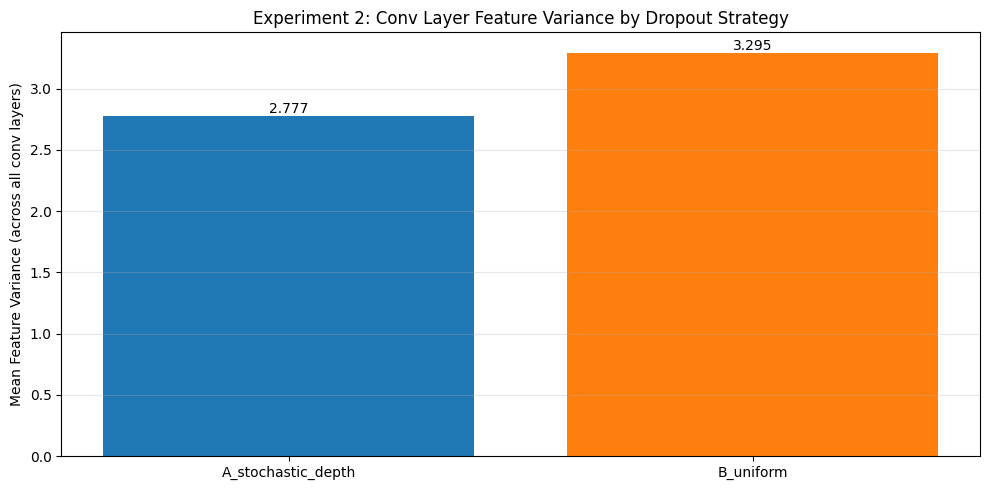

In [7]:
# ── Experiment 2: Auxiliary Diagnostics ──────────────────────────────────────
# Conv layer output feature variance per layer — verify regularization effect
# Collected from seed=42 checkpoints of each group
import argparse
import torch
import matplotlib.pyplot as plt
from Data.io import load_word_char_mats
from Data.squad import SQuADDataset
from Data.loader import make_loader
from Models.qanet import QANet
from Models.encoder import EncoderBlock
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_DIAG_BATCHES = globals().get("NUM_DIAG_BATCHES", 50)

from Models.encoder import EncoderBlock

def collect_conv_feature_variance(save_dir, conv_dropout_mode, num_batches=NUM_DIAG_BATCHES):
    """Load checkpoint and collect per-conv-layer output feature variance on dev data."""
    args = argparse.Namespace(**{**BASELINE_CONFIG,
                                  "conv_dropout_mode": conv_dropout_mode,
                                  "para_limit": 400, "ques_limit": 50, "char_limit": 16,
                                  "num_heads": 8, "glove_dim": 300, "char_dim": 64,
                                  "pretrained_char": False, "init_name": "kaiming",
                                  "activation": "relu", "norm_name": "layer_norm", "norm_groups": 8,
                                  "word_emb_json": "_data/word_emb.json",
                                  "char_emb_json": "_data/char_emb.json"})
    word_mat, char_mat = load_word_char_mats(args)
    model = QANet(word_mat, char_mat, args).to(DEVICE)
    ckpt = torch.load(os.path.join(save_dir, "model.pt"), map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    if "ema_state" in ckpt:
        for name, param in model.named_parameters():
            if name in ckpt["ema_state"]:
                param.data.copy_(ckpt["ema_state"][name])

    # Register hooks on all DepthwiseSeparableConv inside EncoderBlocks
    conv_variances = {}  # "block_name.conv_i" -> list of variances
    hooks = []

    def make_hook(block_name, conv_idx):
        key = f"{block_name}.conv_{conv_idx}"
        conv_variances[key] = []
        def hook_fn(module, input, output):
            # output: [B, C, L] — compute channel-wise variance, then mean over batch
            var_per_channel = output.detach().var(dim=-1).mean(dim=0)  # [C]
            conv_variances[key].append(var_per_channel.mean().item())
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, EncoderBlock):
            for i, conv in enumerate(module.convs):
                h = conv.register_forward_hook(make_hook(name, i))
                hooks.append(h)

    model.eval()
    dev_dataset = SQuADDataset("_data/dev.npz")
    dev_loader = make_loader(dev_dataset, batch_size=8, shuffle=False, pin_memory=False)

    with torch.no_grad():
        for i, batch in enumerate(dev_loader):
            if i >= num_batches:
                break
            Cwid, Ccid, Qwid, Qcid, y1, y2, _ = batch
            model(Cwid.to(DEVICE), Ccid.to(DEVICE), Qwid.to(DEVICE), Qcid.to(DEVICE))

    for h in hooks:
        h.remove()

    return {k: np.mean(v) for k, v in conv_variances.items()}

# Collect for all groups
print("Collecting conv feature variances (seed=42 checkpoints)...\n")
exp2_conv_var = {}
for group_name, mode in exp2_groups:
    save_dir = os.path.join("_exp", "exp2", f"exp2_{group_name}_seed42")
    exp2_conv_var[group_name] = collect_conv_feature_variance(save_dir, mode)

# Print comparison table: aggregate by block type (emb_enc vs model_enc)
print(f"{'Block.Conv':<40}", end="")
for gn, _ in exp2_groups:
    print(f" {gn:>20}", end="")
print()
print("-" * (40 + 20 * len(exp2_groups)))

all_keys = sorted(list(exp2_conv_var[exp2_groups[0][0]].keys()))
for key in all_keys:
    print(f"  {key:<38}", end="")
    for gn, _ in exp2_groups:
        val = exp2_conv_var[gn].get(key, 0.0)
        print(f" {val:>20.4f}", end="")
    print()

# Bar chart: average feature variance per group
fig, ax = plt.subplots(figsize=(10, 5))
group_names = [gn for gn, _ in exp2_groups]
avg_vars = [np.mean(list(exp2_conv_var[gn].values())) for gn in group_names]
bars = ax.bar(group_names, avg_vars, color=["tab:blue", "tab:orange"])
ax.set_ylabel("Mean Feature Variance (across all conv layers)")
ax.set_title("Experiment 2: Conv Layer Feature Variance by Dropout Strategy")
ax.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, avg_vars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join("_exp", "exp2", "exp2_conv_variance.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Experiment 3 — LayerNorm vs RMSNorm: 均值中心化在 QANet 中的必要性

**类别**: 归一化策略 (Normalization Strategy)

**研究问题**: LayerNorm 中的均值中心化（mean-centering）操作对 QANet 的性能贡献是多少？

**理论动机**: RMSNorm (Zhang & Sennrich, 2019) 指出归一化的主要贡献来自方差的缩放不变性，均值中心化可能冗余。RMSNorm 已被 LLaMA、Gemma 等现代架构广泛采用。在 QANet 的 pre-norm 残差结构中，均值偏移是否蕴含有意义的信号？

**假设**:
- **H1**: RMSNorm 可达到与 LayerNorm 统计上无显著差异的 F1/EM
- **H2**: RMSNorm 由于省去均值计算，带来更快的每步训练速度

**自变量**: `norm_name` — 3 种配置

| 组别 | 归一化方法 | 说明 |
|------|-----------|------|
| A (Control) | `layer_norm` | 原始 LayerNorm |
| B (Treatment) | `rms_norm` | RMSNorm — 去除均值中心化 |
| C (Ablation) | `identity` | 无归一化 — 验证归一化本身的必要性 |

**注意**: 运行此实验前需先执行下方的 RMSNorm 注册 cell。

In [ ]:
# ── Experiment 3: Register RMSNorm & IdentityNorm ────────────────────────────
# These are added at runtime so the existing codebase files are not modified.

import torch
import torch.nn as nn
from Models.Normalizations import normalizations

class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization (Zhang & Sennrich, 2019).
    Removes mean-centering; only rescales by RMS. No bias term."""
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        if isinstance(normalized_shape, int):
            normalized_shape = [normalized_shape]
        self.normalized_shape = list(normalized_shape)
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(self.normalized_shape))

    def forward(self, x):
        n = len(self.normalized_shape)
        dims = tuple(range(-n, 0))
        rms = torch.sqrt(torch.mean(x ** 2, dim=dims, keepdim=True) + self.eps)
        return (x / rms) * self.weight


class IdentityNorm(nn.Module):
    """No-op normalization for ablation (passes input through unchanged)."""
    def __init__(self, *args, **kwargs):
        super().__init__()

    def forward(self, x):
        return x


# Patch the get_norm factory to handle the new norm types
from Models.Normalizations.normalization import get_norm as _original_get_norm
from Models.Normalizations import normalization as _norm_module

normalizations["rms_norm"] = RMSNorm
normalizations["identity"] = IdentityNorm

_orig_get_norm = _norm_module.get_norm

def _patched_get_norm(name, d_model, length, num_groups=8):
    if name == "rms_norm":
        return RMSNorm([d_model, 1])
    elif name == "identity":
        return IdentityNorm()
    else:
        return _orig_get_norm(name, d_model, length, num_groups=num_groups)

_norm_module.get_norm = _patched_get_norm

# Also patch the import in encoder.py so it picks up the new factory
import Models.encoder as _enc_module
_enc_module.get_norm = _patched_get_norm

print("Registered normalizations:", list(normalizations.keys()))
print("✓ RMSNorm and IdentityNorm ready for Experiment 3.")

In [ ]:
# ── Experiment 3: Train all groups ───────────────────────────────────────────
# Group A (Control): layer_norm  — original LayerNorm
# Group B:           rms_norm   — RMSNorm (no mean-centering)
# Group C:           identity   — no normalization (ablation)

exp3_groups = [
    ("A_layer_norm", "layer_norm"),
    ("B_rms_norm",   "rms_norm"),
    ("C_identity",   "identity"),
]

exp3_results = {}

for group_name, norm in exp3_groups:
    for seed in SEEDS:
        run_tag  = f"exp3_{group_name}_seed{seed}"
        save_dir = os.path.join("_exp", "exp3", run_tag)
        log_dir  = os.path.join("_exp", "exp3", run_tag, "log")

        print(f"\n{'='*60}")
        print(f"Experiment 3 | {group_name} | seed={seed} | norm_name={norm}")
        print(f"{'='*60}\n")

        results = train(
            **BASELINE_CONFIG,
            seed      = seed,
            save_dir  = save_dir,
            log_dir   = log_dir,
            norm_name = norm,
        )

        exp3_results[run_tag] = {
            "group": group_name,
            "norm": norm,
            "seed": seed,
            "best_f1": results["best_f1"],
            "best_em": results["best_em"],
            "history": results["history"],
        }

        os.makedirs(os.path.join("_exp", "exp3"), exist_ok=True)
        with open(os.path.join("_exp", "exp3", "results.json"), "w") as f:
            json.dump({k: {kk: vv for kk, vv in v.items() if kk != "history"} for k, v in exp3_results.items()}, f, indent=2)

print("\n✓ Experiment 3 training complete.")

In [ ]:
# ── Experiment 3: Full Dev Evaluation ────────────────────────────────────────

exp3_eval = {}

for group_name, norm in exp3_groups:
    f1_list, em_list = [], []
    for seed in SEEDS:
        run_tag  = f"exp3_{group_name}_seed{seed}"
        save_dir = os.path.join("_exp", "exp3", run_tag)
        log_dir  = os.path.join("_exp", "exp3", run_tag, "log")

        metrics = evaluate(
            **EVAL_CONFIG,
            save_dir  = save_dir,
            log_dir   = log_dir,
            norm_name = norm,
        )
        f1_list.append(metrics["f1"])
        em_list.append(metrics["exact_match"])
        print(f"  {run_tag}: F1={metrics['f1']:.4f}  EM={metrics['exact_match']:.4f}")

    exp3_eval[group_name] = {
        "f1_mean": np.mean(f1_list), "f1_std": np.std(f1_list),
        "em_mean": np.mean(em_list), "em_std": np.std(em_list),
        "f1_runs": f1_list, "em_runs": em_list,
    }

print("\n" + "="*60)
print("Experiment 3 Summary (Full Dev Set)")
print("="*60)
for group, vals in exp3_eval.items():
    print(f"  {group:20s}:  F1 = {vals['f1_mean']:.4f} ± {vals['f1_std']:.4f}  |  EM = {vals['em_mean']:.4f} ± {vals['em_std']:.4f}")

In [ ]:
# ── Experiment 3: Training Curves ────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"A_layer_norm": "tab:blue", "B_rms_norm": "tab:orange", "C_identity": "tab:red"}

for group_name, norm in exp3_groups:
    color = colors[group_name]
    all_dev_f1, all_dev_loss, all_train_loss = [], [], []
    for seed in SEEDS:
        run_tag = f"exp3_{group_name}_seed{seed}"
        hist = exp3_results[run_tag]["history"]
        steps = [h["step"] for h in hist]
        all_dev_f1.append([h["dev_f1"] for h in hist])
        all_dev_loss.append([h["dev_loss"] for h in hist])
        all_train_loss.append([h["train_loss"] for h in hist])

    min_len = min(len(x) for x in all_dev_f1)
    steps = steps[:min_len]
    dev_f1_arr = np.array([x[:min_len] for x in all_dev_f1])
    dev_loss_arr = np.array([x[:min_len] for x in all_dev_loss])
    train_loss_arr = np.array([x[:min_len] for x in all_train_loss])

    axes[0].plot(steps, dev_f1_arr.mean(0), color=color, label=group_name)
    axes[0].fill_between(steps, dev_f1_arr.mean(0) - dev_f1_arr.std(0),
                         dev_f1_arr.mean(0) + dev_f1_arr.std(0), alpha=0.15, color=color)

    axes[1].plot(steps, dev_loss_arr.mean(0), color=color, label=group_name)
    axes[1].fill_between(steps, dev_loss_arr.mean(0) - dev_loss_arr.std(0),
                         dev_loss_arr.mean(0) + dev_loss_arr.std(0), alpha=0.15, color=color)

    axes[2].plot(steps, train_loss_arr.mean(0), color=color, label=group_name)

axes[0].set_title("Dev F1 vs Steps"); axes[0].set_ylabel("F1"); axes[0].legend()
axes[1].set_title("Dev Loss vs Steps"); axes[1].set_ylabel("Loss"); axes[1].legend()
axes[2].set_title("Train Loss vs Steps"); axes[2].set_ylabel("Loss"); axes[2].legend()
for ax in axes:
    ax.set_xlabel("Step"); ax.grid(True, alpha=0.3)

fig.suptitle("Experiment 3: Normalization Strategy Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join("_exp", "exp3", "exp3_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Experiment 3: Auxiliary Diagnostics ──────────────────────────────────────
# 1. |μ|_avg: mean magnitude of pre-normalization activations (is mean-centering necessary?)
# 2. Wall-clock time per training step
# 3. Paired t-test between LayerNorm and RMSNorm

from scipy import stats

# ── 1. Pre-norm activation |μ|_avg ──────────────────────────────────────────
def collect_pre_norm_mean_stats(save_dir, norm_name, num_batches=NUM_DIAG_BATCHES):
    """Measure absolute mean of activations just before each norm layer."""
    args = argparse.Namespace(**{**BASELINE_CONFIG, "use_scaled_attn": False,
                                  "conv_dropout_mode": "stochastic_depth",
                                  "para_limit": 400, "ques_limit": 50, "char_limit": 16,
                                  "num_heads": 8, "glove_dim": 300, "char_dim": 64,
                                  "pretrained_char": False, "init_name": "kaiming",
                                  "activation": "relu", "norm_name": norm_name, "norm_groups": 8,
                                  "word_emb_json": "_data/word_emb.json",
                                  "char_emb_json": "_data/char_emb.json"})
    word_mat, char_mat = load_word_char_mats(args)
    model = QANet(word_mat, char_mat, args).to(DEVICE)
    ckpt = torch.load(os.path.join(save_dir, "model.pt"), map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    if "ema_state" in ckpt:
        for name, param in model.named_parameters():
            if name in ckpt["ema_state"]:
                param.data.copy_(ckpt["ema_state"][name])

    abs_means = []
    hooks = []

    def make_hook(layer_name):
        def hook_fn(module, input, output):
            x = input[0] if isinstance(input, tuple) else input
            # channel-wise mean across spatial dim, then abs, then average
            mu = x.detach().mean(dim=-1)  # [B, C] or similar
            abs_means.append(mu.abs().mean().item())
        return hook_fn

    for name, module in model.named_modules():
        if "norm" in name and hasattr(module, "weight"):
            h = module.register_forward_hook(make_hook(name))
            hooks.append(h)

    model.eval()
    dev_dataset = SQuADDataset("_data/dev.npz")
    dev_loader = make_loader(dev_dataset, batch_size=8, shuffle=False, pin_memory=False)
    with torch.no_grad():
        for i, batch in enumerate(dev_loader):
            if i >= num_batches:
                break
            Cwid, Ccid, Qwid, Qcid, y1, y2, _ = batch
            model(Cwid.to(DEVICE), Ccid.to(DEVICE), Qwid.to(DEVICE), Qcid.to(DEVICE))

    for h in hooks:
        h.remove()

    return np.mean(abs_means) if abs_means else 0.0

# Only run for LayerNorm group (the metric measures the actual activations before normalization)
print("Collecting pre-norm |μ|_avg for LayerNorm model (seed=42)...\n")
mu_avg = collect_pre_norm_mean_stats(
    os.path.join("_exp", "exp3", "exp3_A_layer_norm_seed42"), "layer_norm"
)
print(f"  Pre-norm |μ|_avg = {mu_avg:.6f}")
if mu_avg < 0.1:
    print("  → |μ| ≈ 0: mean-centering is approximately a no-op; removing it (RMSNorm) should have minimal impact.")
else:
    print(f"  → |μ| is non-negligible ({mu_avg:.4f}): mean-centering may carry meaningful information.")

# ── 2. Wall-clock time per step (estimated from training history) ────────────
print("\n── Wall-clock: Convergence Speed Proxy ──")
print("  (Comparing steps to reach best dev F1, as an efficiency proxy)\n")
for group_name, norm in exp3_groups:
    run_tag = f"exp3_{group_name}_seed42"
    if run_tag in exp3_results:
        hist = exp3_results[run_tag]["history"]
        best_step = max(hist, key=lambda h: h["dev_f1"])["step"]
        best_f1 = max(h["dev_f1"] for h in hist)
        total_steps = hist[-1]["step"] if hist else 0
        print(f"  {group_name:<16}: best dev F1 = {best_f1:.4f} at step {best_step} (trained {total_steps} steps total)")

# ── 3. Paired t-test: LayerNorm vs RMSNorm ──────────────────────────────────
print("\n── Statistical Significance: Paired t-test ──\n")
if "A_layer_norm" in exp3_eval and "B_rms_norm" in exp3_eval:
    ln_f1 = exp3_eval["A_layer_norm"]["f1_runs"]
    rms_f1 = exp3_eval["B_rms_norm"]["f1_runs"]
    if len(ln_f1) >= 2 and len(rms_f1) >= 2:
        t_stat, p_value = stats.ttest_rel(ln_f1, rms_f1)
        print(f"  LayerNorm F1:  {ln_f1}")
        print(f"  RMSNorm  F1:  {rms_f1}")
        print(f"  Paired t-test: t = {t_stat:.4f}, p = {p_value:.4f}")
        if p_value < 0.05:
            print(f"  → Statistically significant difference (p < 0.05)")
        else:
            print(f"  → No statistically significant difference (p = {p_value:.4f} ≥ 0.05)")
            print(f"  → Supports H1: RMSNorm ≈ LayerNorm in this configuration")
    else:
        print("  Not enough runs for t-test (need at least 2 per group)")
else:
    print("  (Run Experiment 3 evaluation first)")

# LayerNorm vs Identity
if "A_layer_norm" in exp3_eval and "C_identity" in exp3_eval:
    ln_f1 = exp3_eval["A_layer_norm"]["f1_runs"]
    id_f1 = exp3_eval["C_identity"]["f1_runs"]
    if len(ln_f1) >= 2 and len(id_f1) >= 2:
        t_stat, p_value = stats.ttest_rel(ln_f1, id_f1)
        print(f"\n  LayerNorm  F1: {ln_f1}")
        print(f"  Identity   F1: {id_f1}")
        print(f"  Paired t-test: t = {t_stat:.4f}, p = {p_value:.4f}")
        if p_value < 0.05:
            print(f"  → Normalization significantly matters (p < 0.05)")
        else:
            print(f"  → No significant difference — normalization may be redundant here")

---
## All Experiments — Summary Table

In [ ]:
# ── All Experiments: Combined Summary Table ──────────────────────────────────

print("="*80)
print("  STAGE 3 EXPERIMENT RESULTS — Full Dev Set (mean ± std over 3 seeds)")
print("="*80)

print("\n── Experiment 1: Attention Scaling ──")
print(f"  {'Group':<15} {'F1':>20} {'EM':>20}")
print(f"  {'-'*55}")
for group, vals in exp1_eval.items():
    print(f"  {group:<15} {vals['f1_mean']:>8.4f} ± {vals['f1_std']:<8.4f} {vals['em_mean']:>8.4f} ± {vals['em_std']:<8.4f}")

print("\n── Experiment 2: Conv Dropout Strategy ──")
print(f"  {'Group':<32} {'F1':>20} {'EM':>20}")
print(f"  {'-'*72}")
for group, vals in exp2_eval.items():
    print(f"  {group:<32} {vals['f1_mean']:>8.4f} ± {vals['f1_std']:<8.4f} {vals['em_mean']:>8.4f} ± {vals['em_std']:<8.4f}")

print("\n── Experiment 3: Normalization Strategy ──")
print(f"  {'Group':<22} {'F1':>20} {'EM':>20}")
print(f"  {'-'*62}")
for group, vals in exp3_eval.items():
    print(f"  {group:<22} {vals['f1_mean']:>8.4f} ± {vals['f1_std']:<8.4f} {vals['em_mean']:>8.4f} ± {vals['em_std']:<8.4f}")

print("\n" + "="*80)